# Task 3: Data Visualization Dashboard

## Dataset: Supermarket Sales

### Objective

To create meaningful visualizations and a dashboard using Python and Matplotlib to communicate important insights from supermarket sales data.

### Purpose

The dashboard presents sales trends, branch performance, product-line performance, payment preferences, customer distribution, and the relationship between quantity sold and sales.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
sales = pd.read_csv("SuperMarket Analysis.csv")

print("Dataset loaded successfully!")
sales.head()

Dataset loaded successfully!


,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


In [5]:
print("Rows and Columns:", sales.shape)
print("\nColumn Names:")
print(sales.columns.tolist())

Rows and Columns: (1000, 17)

Column Names:
['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender', 'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Sales', 'Date', 'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income', 'Rating']


In [6]:
sales["Date"] = pd.to_datetime(sales["Date"], errors="coerce")

print("Date column converted successfully!")

Date column converted successfully!


## Branch sales

In [7]:
branch_sales = sales.groupby("Branch")["Sales"].sum().sort_values(ascending=False)

branch_sales

Branch
Giza     110568.7065
Alex     106200.3705
Cairo    106197.6720
Name: Sales, dtype: float64

## Product-line sales

In [8]:
product_sales = sales.groupby("Product line")["Sales"].sum().sort_values(ascending=False)

product_sales

Product line
Food and beverages        56144.8440
Sports and travel         55122.8265
Electronic accessories    54337.5315
Fashion accessories       54305.8950
Home and lifestyle        53861.9130
Health and beauty         49193.7390
Name: Sales, dtype: float64

## Payment methods

In [9]:
payment_counts = sales["Payment"].value_counts()

payment_counts

Payment
Ewallet        345
Cash           344
Credit card    311
Name: count, dtype: int64

## Customer types

In [10]:
customer_counts = sales["Customer type"].value_counts()

customer_counts

Customer type
Member    565
Normal    435
Name: count, dtype: int64

## Gender distribution

In [11]:
gender_counts = sales["Gender"].value_counts()

gender_counts

Gender
Female    571
Male      429
Name: count, dtype: int64

## Daily sales

In [12]:
daily_sales = sales.groupby("Date")["Sales"].sum()

daily_sales

Date
2019-01-01    4745.1810
2019-01-02    1945.5030
2019-01-03    2078.1285
2019-01-04    1623.6885
2019-01-05    3536.6835
                ...    
2019-03-26    1962.5130
2019-03-27    2902.8195
2019-03-28    2229.4020
2019-03-29    4023.2430
2019-03-30    4487.0595
Name: Sales, Length: 89, dtype: float64

## Visualization 1: Sales by Branch

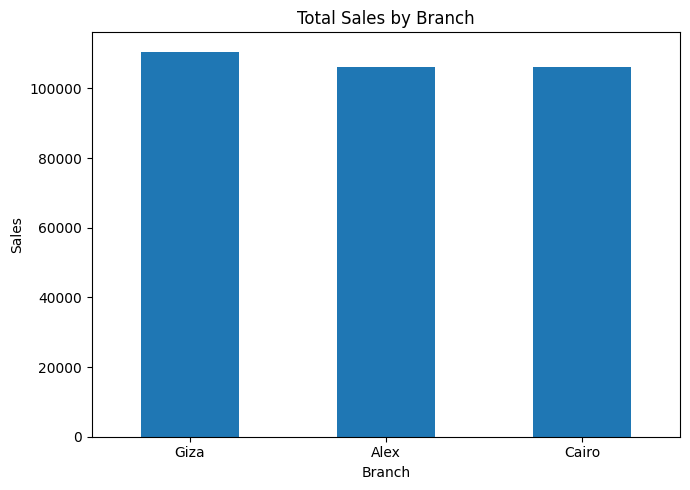

In [13]:
plt.figure(figsize=(7, 5))

branch_sales.plot(kind="bar")

plt.title("Total Sales by Branch")
plt.xlabel("Branch")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Visualization 2: Sales by Product Line

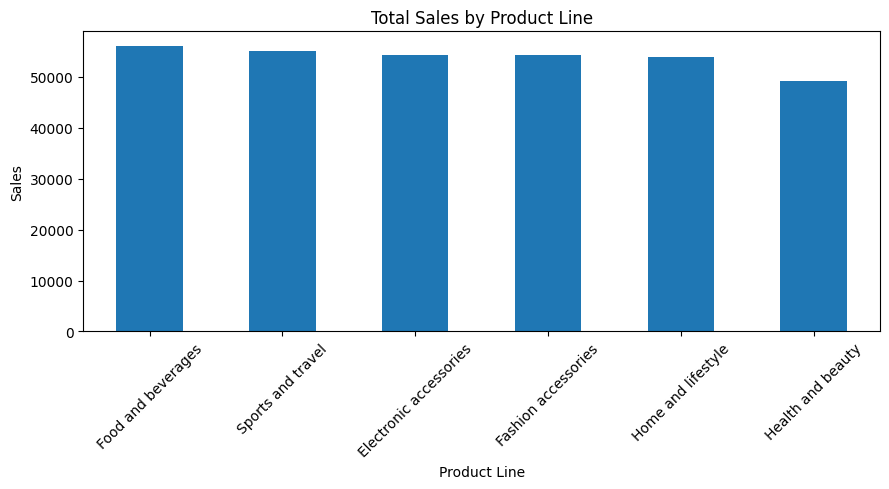

In [14]:
plt.figure(figsize=(9, 5))

product_sales.plot(kind="bar")

plt.title("Total Sales by Product Line")
plt.xlabel("Product Line")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Visualization 3: Daily Sales Trend

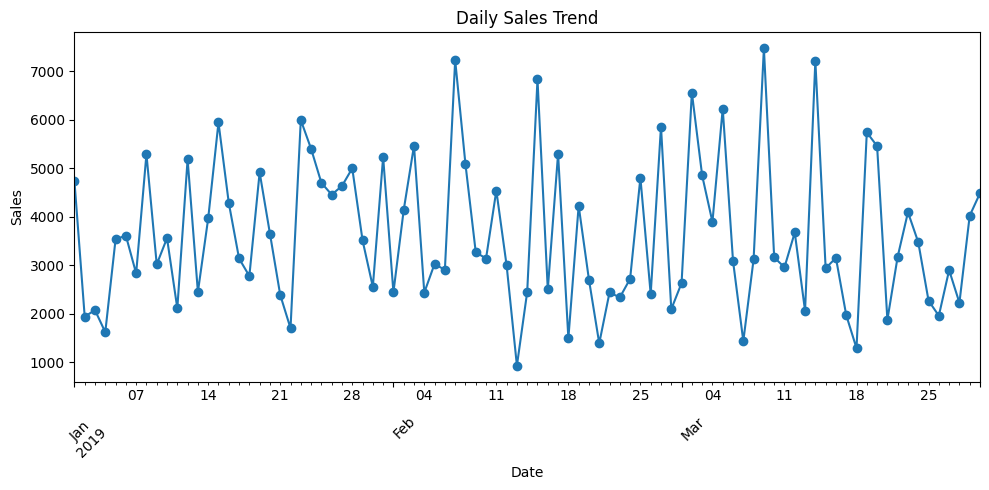

In [15]:
plt.figure(figsize=(10, 5))

daily_sales.plot(kind="line", marker="o")

plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Visualization 4: Payment Methods

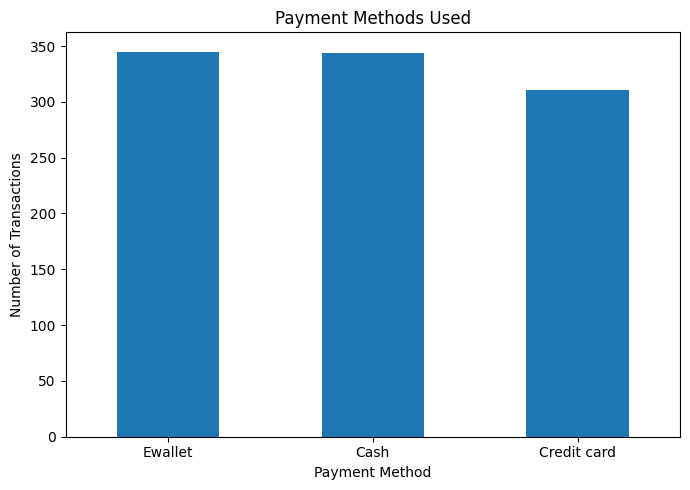

In [16]:
plt.figure(figsize=(7, 5))

payment_counts.plot(kind="bar")

plt.title("Payment Methods Used")
plt.xlabel("Payment Method")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Visualization 5: Customer Type Distribution

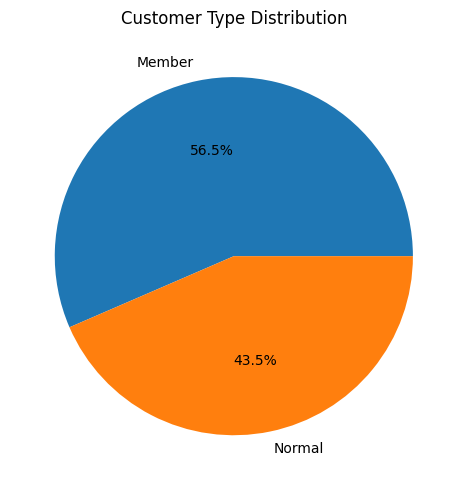

In [17]:
plt.figure(figsize=(7, 5))

customer_counts.plot(kind="pie", autopct="%1.1f%%")

plt.title("Customer Type Distribution")
plt.ylabel("")
plt.tight_layout()
plt.show()

## Visualization 6: Quantity vs Sales

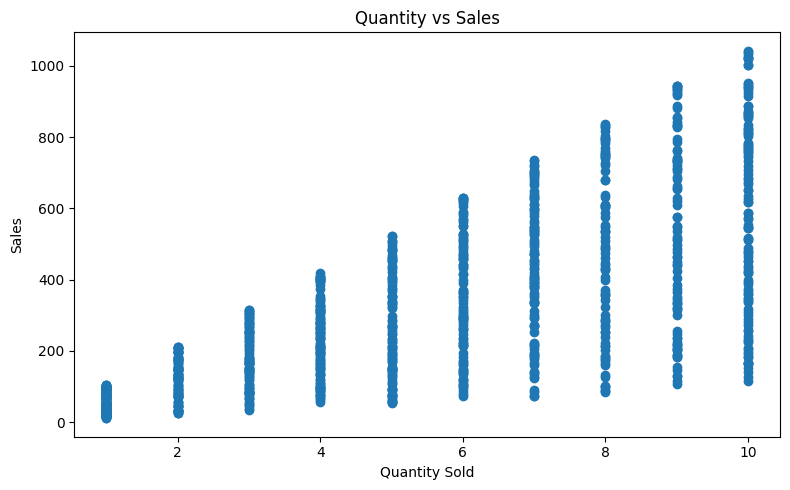

In [18]:
plt.figure(figsize=(8, 5))

plt.scatter(sales["Quantity"], sales["Sales"])

plt.title("Quantity vs Sales")
plt.xlabel("Quantity Sold")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

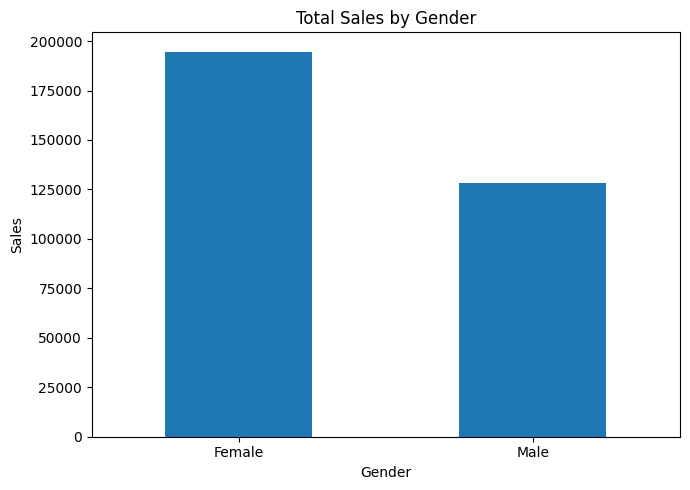

In [19]:
gender_sales = sales.groupby("Gender")["Sales"].sum()

plt.figure(figsize=(7, 5))

gender_sales.plot(kind="bar")

plt.title("Total Sales by Gender")
plt.xlabel("Gender")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Dashboard

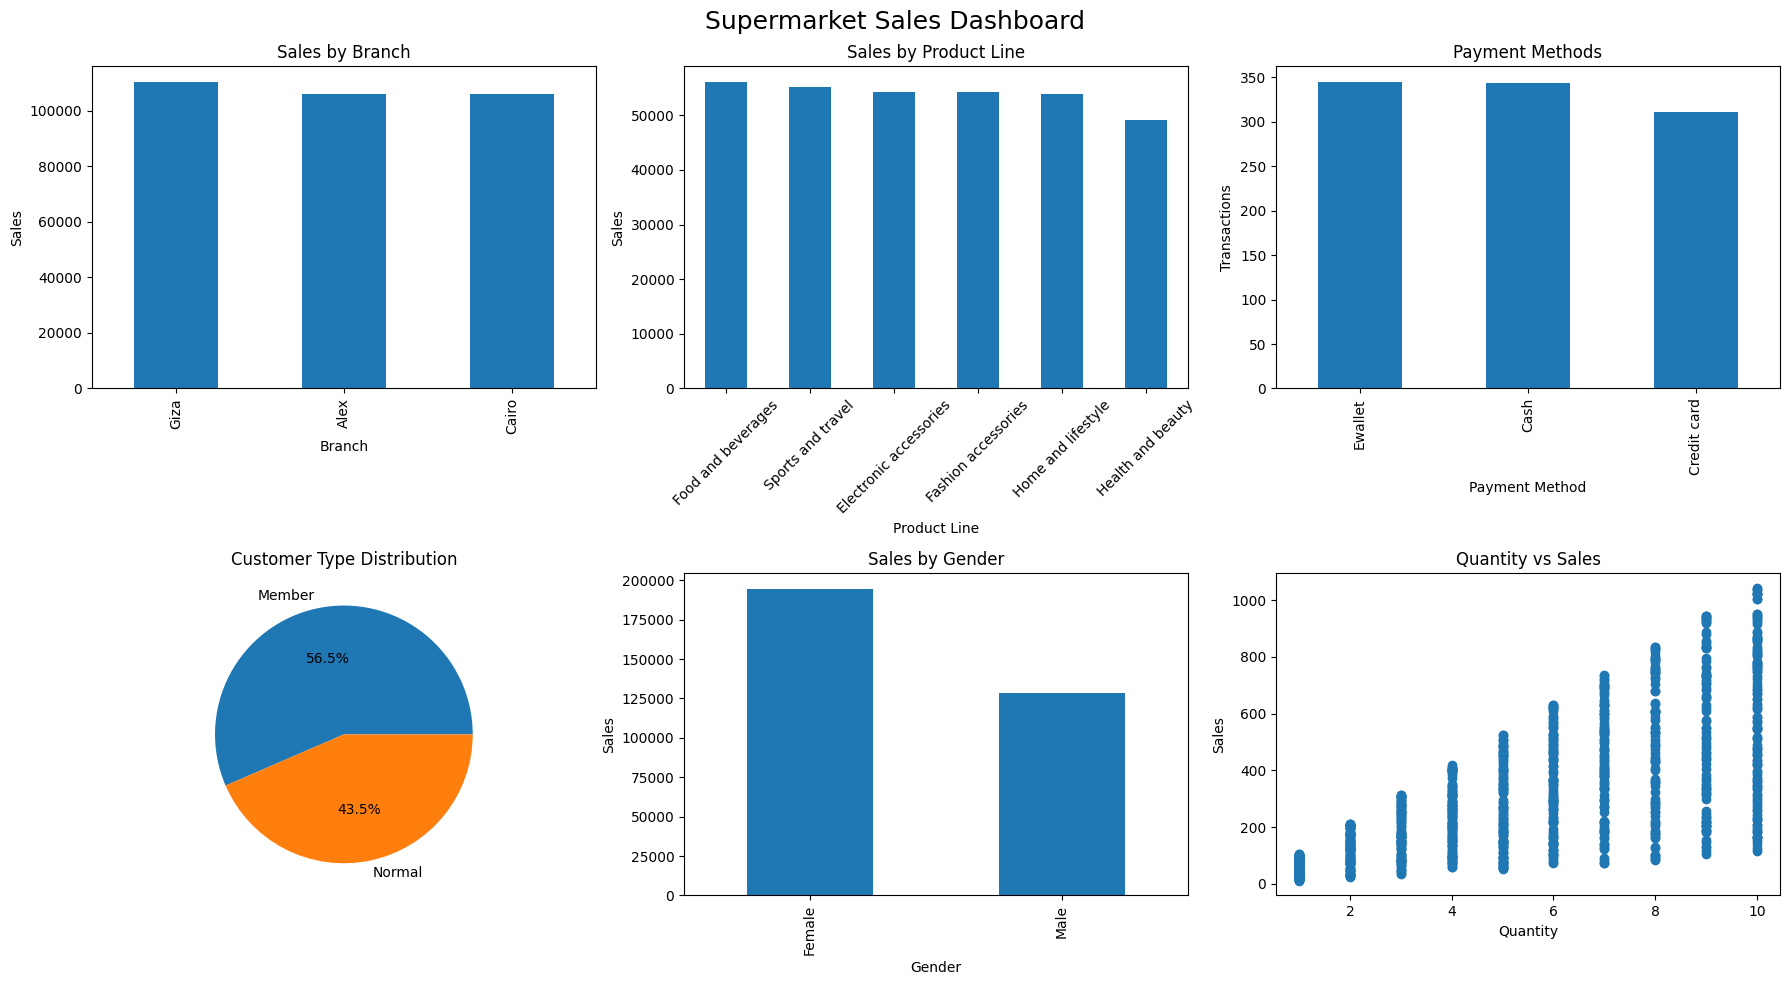

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Branch Sales
branch_sales.plot(kind="bar", ax=axes[0, 0])
axes[0, 0].set_title("Sales by Branch")
axes[0, 0].set_xlabel("Branch")
axes[0, 0].set_ylabel("Sales")

# 2. Product Line Sales
product_sales.plot(kind="bar", ax=axes[0, 1])
axes[0, 1].set_title("Sales by Product Line")
axes[0, 1].set_xlabel("Product Line")
axes[0, 1].set_ylabel("Sales")
axes[0, 1].tick_params(axis="x", rotation=45)

# 3. Payment Methods
payment_counts.plot(kind="bar", ax=axes[0, 2])
axes[0, 2].set_title("Payment Methods")
axes[0, 2].set_xlabel("Payment Method")
axes[0, 2].set_ylabel("Transactions")

# 4. Customer Types
customer_counts.plot(kind="pie", autopct="%1.1f%%", ax=axes[1, 0])
axes[1, 0].set_title("Customer Type Distribution")
axes[1, 0].set_ylabel("")

# 5. Gender Sales
gender_sales.plot(kind="bar", ax=axes[1, 1])
axes[1, 1].set_title("Sales by Gender")
axes[1, 1].set_xlabel("Gender")
axes[1, 1].set_ylabel("Sales")

# 6. Quantity vs Sales
axes[1, 2].scatter(sales["Quantity"], sales["Sales"])
axes[1, 2].set_title("Quantity vs Sales")
axes[1, 2].set_xlabel("Quantity")
axes[1, 2].set_ylabel("Sales")

plt.suptitle("Supermarket Sales Dashboard", fontsize=18)

plt.tight_layout()

plt.savefig("dashboard.png", dpi=300, bbox_inches="tight")

plt.show()

## daily trend

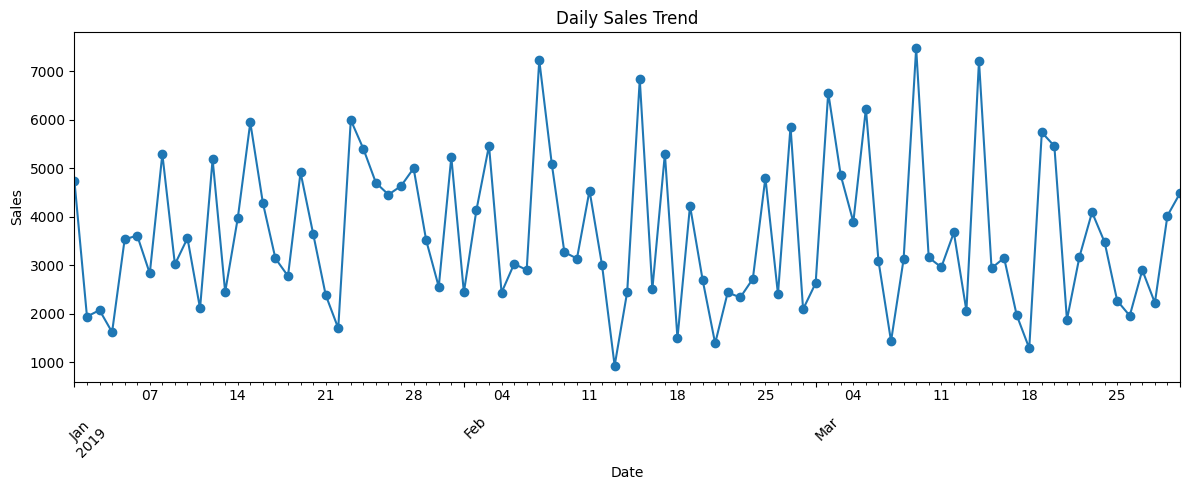

In [22]:
plt.figure(figsize=(12, 5))

daily_sales.plot(kind="line", marker="o")

plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("daily_sales_trend.png", dpi=300, bbox_inches="tight")

plt.show()

# Dashboard Insights

## Key Insights

1. Branch-wise sales analysis helps identify the branch contributing the highest total sales.

2. Product-line analysis shows which categories generate the greatest sales revenue.

3. The daily sales trend shows fluctuations in supermarket sales over time.

4. Payment-method analysis identifies the most frequently used payment option among customers.

5. Customer-type analysis compares the proportion of members and normal customers.

6. Gender-wise sales analysis provides an overview of sales distribution between customer groups.

7. The quantity-versus-sales scatter plot helps examine the relationship between the number of products sold and total sales.

8. The dashboard provides a visual summary of important sales and customer-related patterns in the dataset.

# Conclusion

The visualization dashboard provides a clear overview of supermarket sales performance. Different charts were used to analyze branch performance, product-line sales, customer characteristics, payment preferences, and sales relationships. The visualizations make it easier to identify important patterns and trends in the dataset and support better understanding of the business data.